In [1]:
pip install missingno


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
sns.set(style='darkgrid')

I have loaded the ML-Edge IIoT dataset from the Edge IIoT collection and installed the necessary libraries. The dataset includes both normal and attack traffic, with the majority of the traffic belonging to the normal category. It contains 157,800 rows and 63 columns, resulting in a total of 9,941,400 data cells (rows × columns).

In [3]:
data = pd.read_csv('/home/anya/ca_project/comparative_analysis/ML-EdgeIIoT-dataset.csv')

/tmp/ipykernel_357986/3743677383.py:1: DtypeWarning: Columns (3,6,11,13,14,15,16,17,31,32,34,39,45,51,54,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/anya/ca_project/comparative_analysis/ML-EdgeIIoT-dataset.csv')


In [4]:
def get_type_missing(data):
    data_types = pd.DataFrame()
    data_types['data_type'] = data.dtypes
    data_types['missing_values'] = data.isnull().sum()
    return data_types.sort_values(by='missing_values', ascending=False)


In [5]:
def categorize_attack(row):
    if row["Attack_type"] == "Normal":
        return 0 
    else:
        return 1 

In [6]:
print(data.dtypes)  # Check the data types of each column

frame.time             object
ip.src_host            object
ip.dst_host            object
arp.dst.proto_ipv4     object
arp.opcode            float64
                       ...   
mbtcp.len             float64
mbtcp.trans_id        float64
mbtcp.unit_id         float64
Attack_label            int64
Attack_type            object
Length: 63, dtype: object


In [7]:
rows, cols = data.shape
print(f'Number of rows: {rows}')
print(f'Number of columns: {cols}')
print(f'Total cells: {rows * cols}')

Number of rows: 157800
Number of columns: 63
Total cells: 9941400


In [8]:
# Renaming the columns by removing leading/trailing whitespace
col_names = {col: col.strip() for col in data.columns}
data.rename(columns = col_names, inplace = True)

In [9]:
data.columns

Index(['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4',
       'arp.opcode', 'arp.hw.size', 'arp.src.proto_ipv4', 'icmp.checksum',
       'icmp.seq_le', 'icmp.transmit_timestamp', 'icmp.unused',
       'http.file_data', 'http.content_length', 'http.request.uri.query',
       'http.request.method', 'http.referer', 'http.request.full_uri',
       'http.request.version', 'http.response', 'http.tls_port', 'tcp.ack',
       'tcp.ack_raw', 'tcp.checksum', 'tcp.connection.fin',
       'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack',
       'tcp.dstport', 'tcp.flags', 'tcp.flags.ack', 'tcp.len', 'tcp.options',
       'tcp.payload', 'tcp.seq', 'tcp.srcport', 'udp.port', 'udp.stream',
       'udp.time_delta', 'dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu',
       'dns.qry.type', 'dns.retransmission', 'dns.retransmit_request',
       'dns.retransmit_request_in', 'mqtt.conack.flags',
       'mqtt.conflag.cleansess', 'mqtt.conflags', 'mqtt.hdrflags', 'mqtt.len

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157800 entries, 0 to 157799
Data columns (total 63 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   frame.time                 157800 non-null  object 
 1   ip.src_host                157800 non-null  object 
 2   ip.dst_host                157800 non-null  object 
 3   arp.dst.proto_ipv4         157800 non-null  object 
 4   arp.opcode                 157800 non-null  float64
 5   arp.hw.size                157800 non-null  float64
 6   arp.src.proto_ipv4         157800 non-null  object 
 7   icmp.checksum              157800 non-null  float64
 8   icmp.seq_le                157800 non-null  float64
 9   icmp.transmit_timestamp    157800 non-null  float64
 10  icmp.unused                157800 non-null  float64
 11  http.file_data             157800 non-null  object 
 12  http.content_length        157800 non-null  float64
 13  http.request.uri.query     15

In [11]:
pd.options.display.max_rows = 63

print('Overview of Columns:')
data.describe().transpose()

Overview of Columns:


,count,mean,std,min,25%,50%,75%,max
arp.opcode,157800.0,1.419518e-02,1.497828e-01,0.0,0.0,0.000000e+00,0.000000e+00,2.000000e+00
arp.hw.size,157800.0,5.984791e-02,5.962449e-01,0.0,0.0,0.000000e+00,0.000000e+00,6.000000e+00
icmp.checksum,157800.0,3.047292e+03,1.114433e+04,0.0,0.0,0.000000e+00,0.000000e+00,6.553200e+04
icmp.seq_le,157800.0,3.239980e+03,1.140607e+04,0.0,0.0,0.000000e+00,0.000000e+00,6.552400e+04
icmp.transmit_timestamp,157800.0,4.046816e+04,1.764075e+06,0.0,0.0,0.000000e+00,0.000000e+00,7.728902e+07
icmp.unused,157800.0,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00
http.content_length,157800.0,1.471552e+01,2.296597e+02,0.0,0.0,0.000000e+00,0.000000e+00,8.365500e+04
http.response,157800.0,4.574778e-02,2.089383e-01,0.0,0.0,0.000000e+00,0.000000e+00,1.000000e+00
http.tls_port,157800.0,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00
tcp.ack,157800.0,7.160039e+07,3.101231e+08,0.0,0.0,1.000000e+00,4.790000e+02,2.147333e+09


In [12]:
pd.options.display.max_columns = 63
data

,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,icmp.unused,http.file_data,http.content_length,http.request.uri.query,http.request.method,http.referer,http.request.full_uri,http.request.version,http.response,http.tls_port,tcp.ack,tcp.ack_raw,tcp.checksum,tcp.connection.fin,tcp.connection.rst,tcp.connection.syn,tcp.connection.synack,tcp.dstport,tcp.flags,tcp.flags.ack,tcp.len,tcp.options,tcp.payload,tcp.seq,tcp.srcport,udp.port,udp.stream,udp.time_delta,dns.qry.name,dns.qry.name.len,dns.qry.qu,dns.qry.type,dns.retransmission,dns.retransmit_request,dns.retransmit_request_in,mqtt.conack.flags,mqtt.conflag.cleansess,mqtt.conflags,mqtt.hdrflags,mqtt.len,mqtt.msg_decoded_as,mqtt.msg,mqtt.msgtype,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
1,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
2,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
3,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
4,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157795,2021 23:24:32.698981000,193.152.82.43,192.168.0.128,0,0.0,0.0,0,48729.0,40690.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,DDoS_ICMP
157796,2021 23:24:32.699354000,253.52.1.213,192.168.0.128,0,0.0,0.0,0,45657.0,40702.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,DDoS_ICMP
157797,2021 23:24:32.719931000,107.155.221.49,192.168.0.128,0,0.0,0.0,0,57686.0,41423.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,DDoS_ICMP
157798,2021 23:24:32.752054000,77.242.58.228,192.168.0.128,0,0.0,0.0,0,9555.0,42379.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,DDoS_ICMP


In [13]:
Results = set(data['Attack_type'].values)
print(Results,end=" ")

{'DDoS_HTTP', 'Backdoor', 'DDoS_ICMP', 'Normal', 'DDoS_UDP', 'Password', 'SQL_injection', 'Vulnerability_scanner', 'XSS', 'DDoS_TCP', 'Fingerprinting', 'Port_Scanning', 'Ransomware', 'MITM', 'Uploading'} 

DATA CLEANING 

In [14]:
dups = data[data.duplicated()]
print(f'Number of duplicates: {len(dups)}')

Number of duplicates: 814


In [15]:
data.drop_duplicates(inplace = True)
data.shape

(156986, 63)

In [16]:
missing_val = data.isna().sum()
print(missing_val.loc[missing_val > 0])

Series([], dtype: int64)


In [17]:
numeric_cols = data.select_dtypes(include = np.number).columns
inf_count = np.isinf(data[numeric_cols]).sum()
print(inf_count[inf_count > 0])

Series([], dtype: int64)


THERE ARE NO MISSING OR INFINITE VALUES


In [18]:
data['Attack_label'].unique()

array([1, 0])

In [19]:
data.groupby('Attack_label').size()


Attack_label
0     24301
1    132685
dtype: int64

In [20]:
print(data[['Attack_label', 'Attack_type']].drop_duplicates())


        Attack_label            Attack_type
0                  1                   MITM
1214               1         Fingerprinting
2215               1             Ransomware
13140              1              Uploading
23409              1          SQL_injection
33720              1              DDoS_HTTP
44281              1               DDoS_TCP
54528              1               Password
64517              1          Port_Scanning
74588              1  Vulnerability_scanner
84664              1               Backdoor
94859              1                    XSS
104911             0                 Normal
129212             1               DDoS_UDP
143710             1              DDoS_ICMP


In [21]:
Results = set(data['Attack_type'].values)
print(Results,end=" ")

{'DDoS_HTTP', 'Backdoor', 'DDoS_ICMP', 'Normal', 'DDoS_UDP', 'Password', 'SQL_injection', 'Vulnerability_scanner', 'XSS', 'DDoS_TCP', 'Fingerprinting', 'Port_Scanning', 'Ransomware', 'MITM', 'Uploading'} 

In [22]:
# Get unique attack types along with their numeric codes
attack_mapping = data[['Attack_type']].drop_duplicates().reset_index(drop=True)
attack_mapping['Attack_type_code'] = attack_mapping.index

print(attack_mapping)


              Attack_type  Attack_type_code
0                    MITM                 0
1          Fingerprinting                 1
2              Ransomware                 2
3               Uploading                 3
4           SQL_injection                 4
5               DDoS_HTTP                 5
6                DDoS_TCP                 6
7                Password                 7
8           Port_Scanning                 8
9   Vulnerability_scanner                 9
10               Backdoor                10
11                    XSS                11
12                 Normal                12
13               DDoS_UDP                13
14              DDoS_ICMP                14


In [23]:
categorical_cols = data.select_dtypes(include=['object', 'category']).columns
print("Categorical columns:")
print(categorical_cols)

Categorical columns:
Index(['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4',
       'arp.src.proto_ipv4', 'http.file_data', 'http.request.uri.query',
       'http.request.method', 'http.referer', 'http.request.full_uri',
       'http.request.version', 'tcp.options', 'tcp.payload', 'tcp.srcport',
       'dns.qry.name.len', 'mqtt.conack.flags', 'mqtt.msg', 'mqtt.protoname',
       'mqtt.topic', 'Attack_type'],
      dtype='object')


DATA PREPROCESSING 

In [24]:
data.head()

,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,icmp.unused,http.file_data,http.content_length,http.request.uri.query,http.request.method,http.referer,http.request.full_uri,http.request.version,http.response,http.tls_port,tcp.ack,tcp.ack_raw,tcp.checksum,tcp.connection.fin,tcp.connection.rst,tcp.connection.syn,tcp.connection.synack,tcp.dstport,tcp.flags,tcp.flags.ack,tcp.len,tcp.options,tcp.payload,tcp.seq,tcp.srcport,udp.port,udp.stream,udp.time_delta,dns.qry.name,dns.qry.name.len,dns.qry.qu,dns.qry.type,dns.retransmission,dns.retransmit_request,dns.retransmit_request_in,mqtt.conack.flags,mqtt.conflag.cleansess,mqtt.conflags,mqtt.hdrflags,mqtt.len,mqtt.msg_decoded_as,mqtt.msg,mqtt.msgtype,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
1,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
8,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
29,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,68.0,67.0,2.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
30,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,65228.0,5355.0,3.0,0.0,DESKTOP-UHF0SF2,15.0,0.0,255.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM


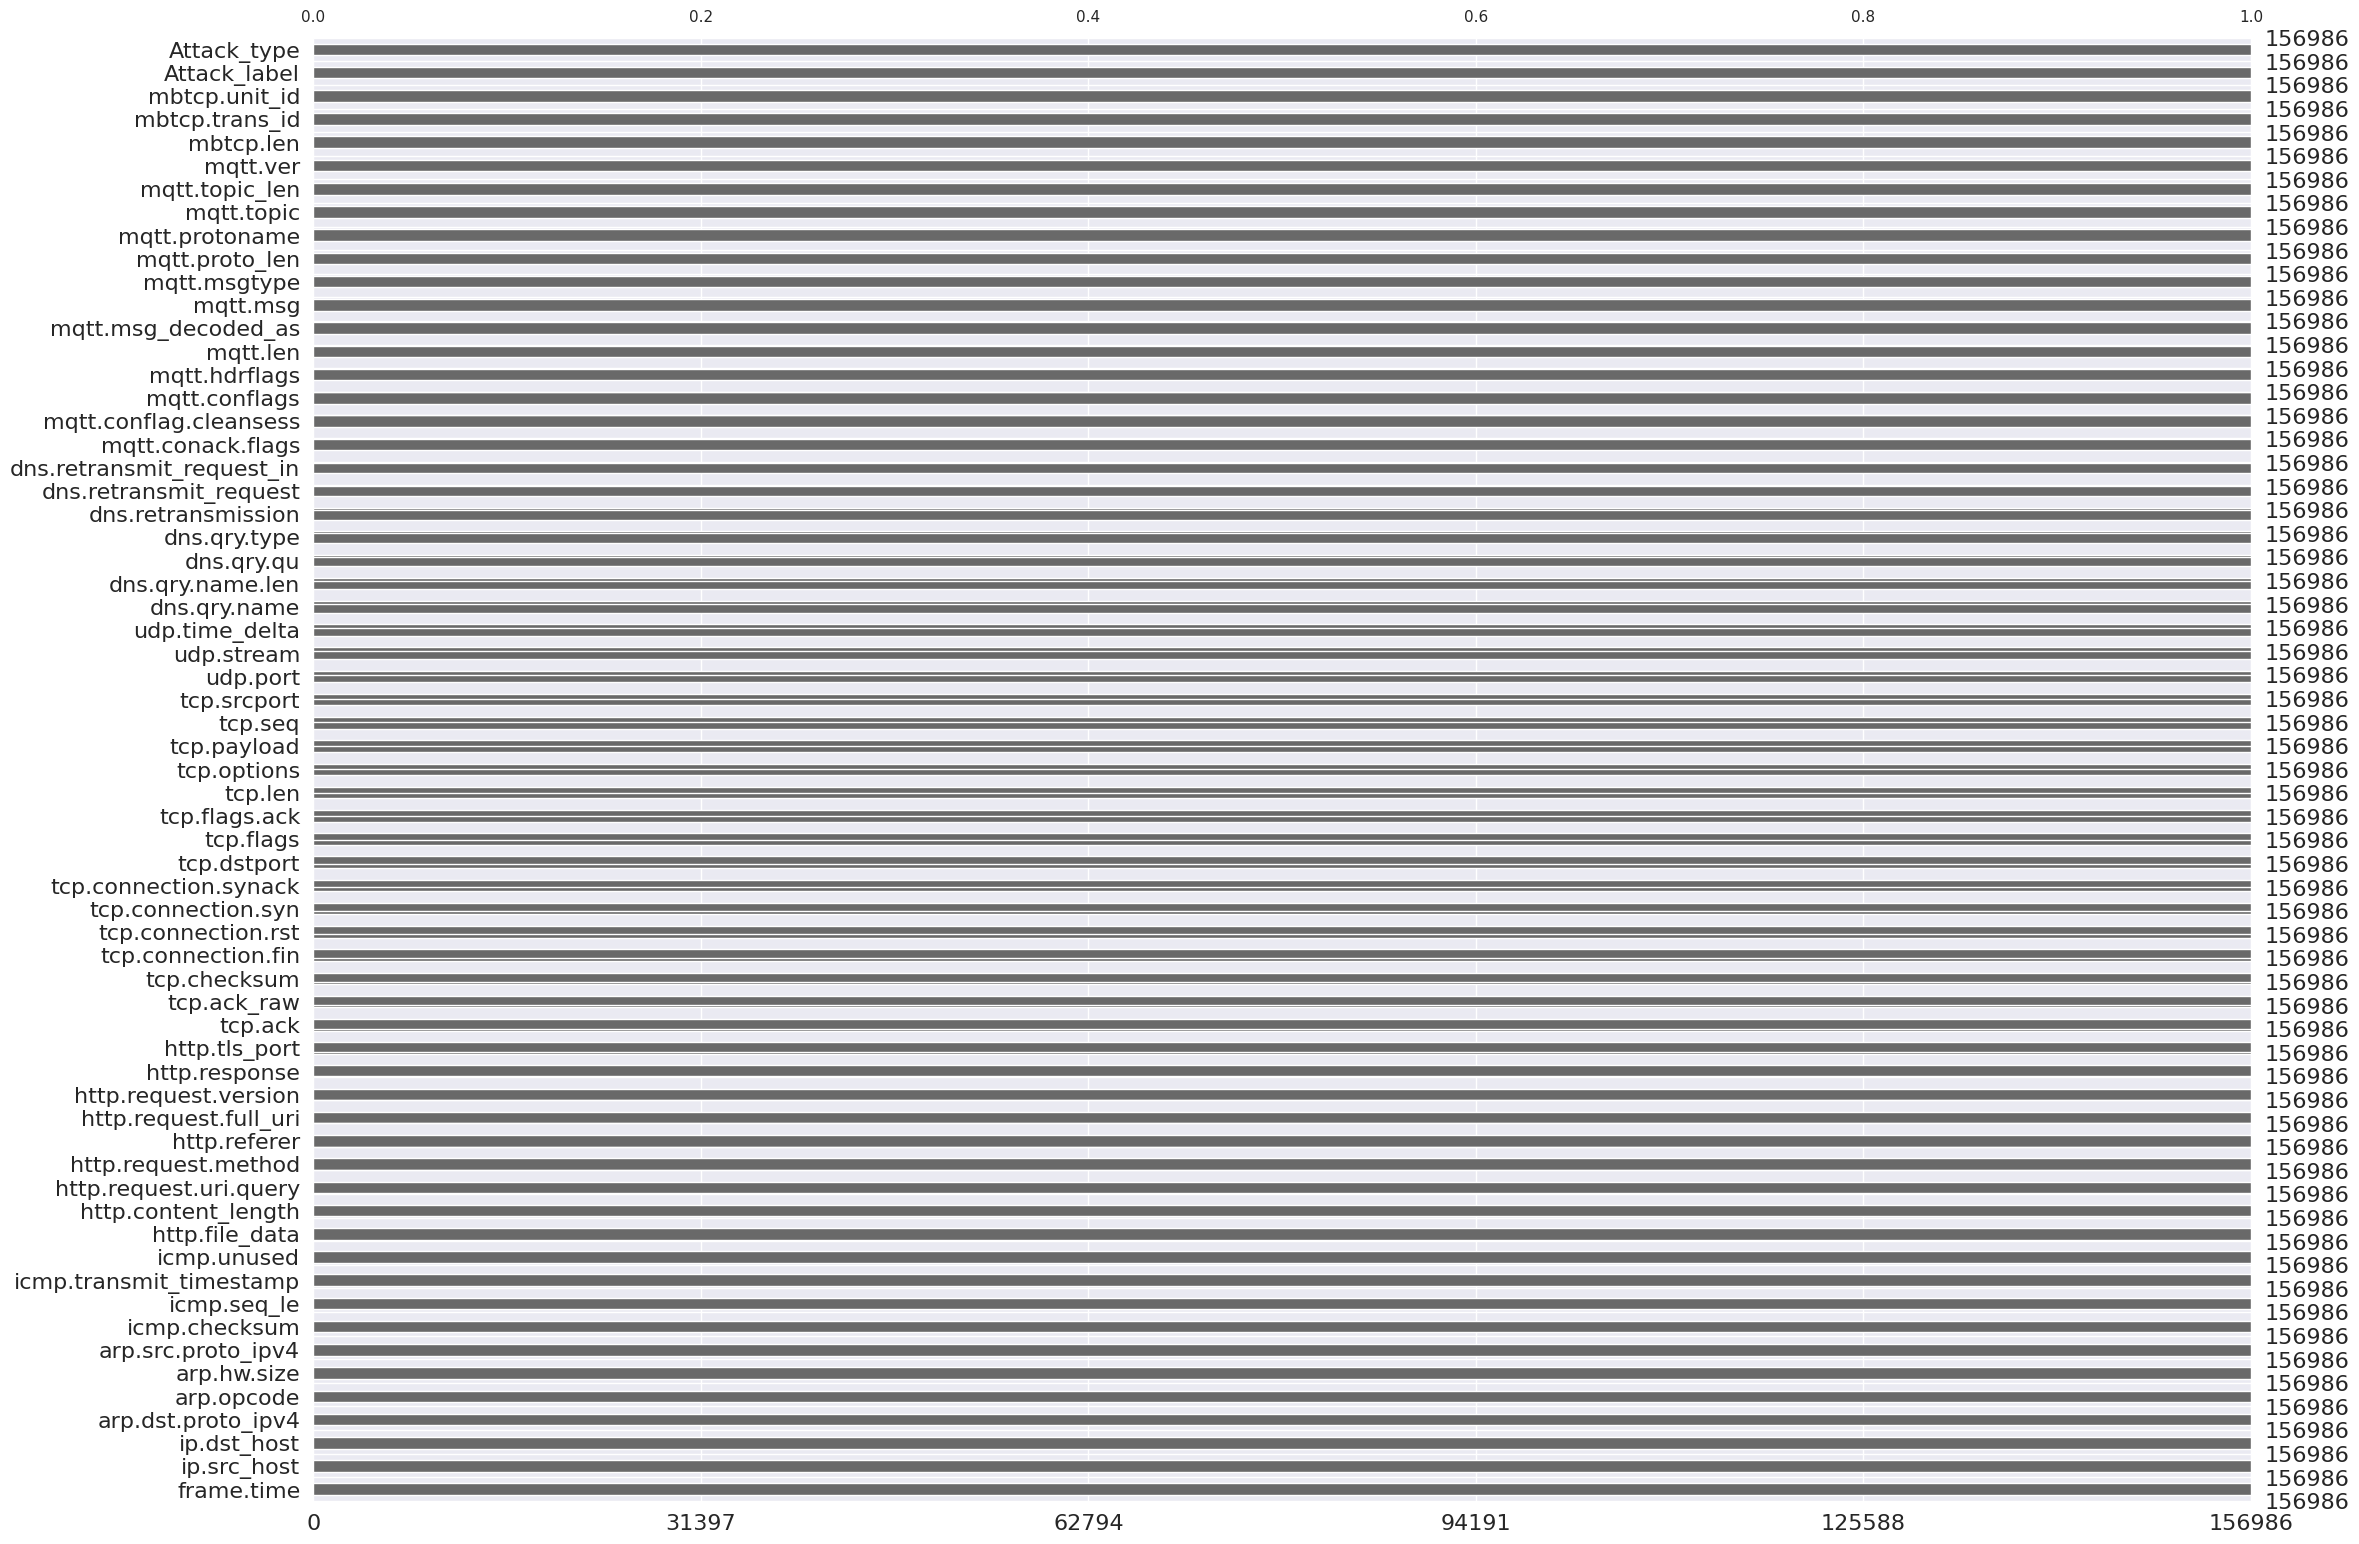

In [25]:
msno.bar(data)
plt.show() 


In [26]:


print(data['frame.time'].value_counts().head())

print("\nNull Values:")
print(data['frame.time'].isna().sum())



frame.time
192.168.0.128                1402
0.0                           394
6.0                             6
 2021 23:12:11.894359000        2
 2021 19:50:38.945378000        1
Name: count, dtype: int64

Null Values:
0


In [27]:


# converting to datetime
def convert_to_datetime(value):
    try:
        return pd.to_datetime(value)
    except:
        return np.nan
    
data['frame.time'] = data['frame.time'].apply(convert_to_datetime)



In [28]:
print(data['ip.src_host'].value_counts().head())
print('_________________________________________________________')
print(data['ip.dst_host'].value_counts().head())
print('_________________________________________________________')
print(data['arp.src.proto_ipv4'].value_counts().head())
print('_________________________________________________________')
print(data['arp.dst.proto_ipv4'].value_counts().head())


ip.src_host
192.168.0.128    72543
192.168.0.170    47687
192.168.0.101     9972
0                 7512
0.0.0.0            151
Name: count, dtype: int64
_________________________________________________________
ip.dst_host
192.168.0.128    75373
192.168.0.170    42290
0                20214
192.168.0.101    10097
0.0                400
Name: count, dtype: int64
_________________________________________________________
arp.src.proto_ipv4
0                110040
0                 43112
0.0                2260
192.168.0.128       683
192.168.0.170       562
Name: count, dtype: int64
_________________________________________________________
arp.dst.proto_ipv4
0                126882
0                 26728
192.168.0.128      2052
192.168.0.170       595
0.0                 400
Name: count, dtype: int64


In [29]:
data['Attack_label'].value_counts()

Attack_label
1    132685
0     24301
Name: count, dtype: int64

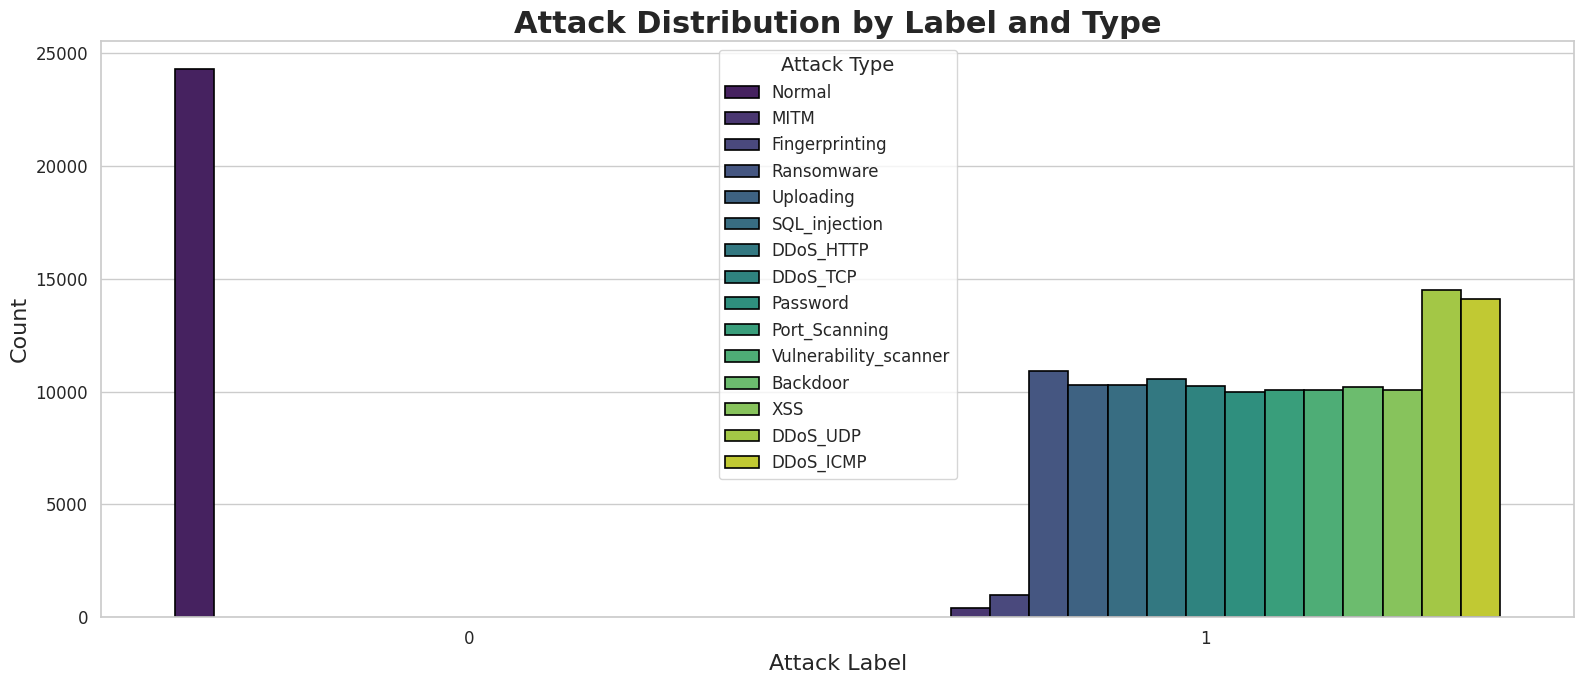

In [30]:
# Set a beautiful style
sns.set_style('whitegrid')

# Create the figure
plt.figure(figsize=(16, 7))
plot = sns.countplot(
    data=data, 
    x='Attack_label', 
    hue='Attack_type', 
    edgecolor='black', 
    linewidth=1.2,
    palette='viridis'  # Cool color palette
)

# Add titles and labels
plt.title('Attack Distribution by Label and Type', fontsize=22, fontweight='bold')
plt.xlabel('Attack Label', fontsize=16)
plt.ylabel('Count', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Attack Type', title_fontsize=14, fontsize=12)
plt.tight_layout()

# Show the plot
plt.show()


In [31]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [32]:
import plotly.express as px

fig = px.pie(data, names='Attack_label', title='Distribution of Attack Labels')
fig.show()

In [33]:


fig = px.pie(data, names='Attack_type', title='Distribution of Attack Type')
fig.show()



In [34]:
data['mqtt.topic'].value_counts()

mqtt.topic
0.0                         124218
0                            23055
0.0                           8467
Temperature_and_Humidity      1246
Name: count, dtype: int64

In [35]:
data['mqtt.protoname'].value_counts()

mqtt.protoname
0.0     124218
0        23051
0.0       8467
MQTT      1250
Name: count, dtype: int64

In [36]:
data['dns.qry.name.len'].value_counts()

dns.qry.name.len
0.0                       140375
0                          14495
0.0                         1860
1.0                          227
1.debian.pool.ntp.org         10
0.debian.pool.ntp.org          8
3.debian.pool.ntp.org          7
2.debian.pool.ntp.org          3
_googlecast._tcp.local         1
Name: count, dtype: int64

In [37]:


data['http.request.method'].value_counts()


http.request.method
0          54062
0.0        52616
0.0        43112
GET         6676
POST         267
TRACE        252
OPTIONS        1
Name: count, dtype: int64

In [38]:
drop_columns = ["frame.time", "ip.src_host", "ip.dst_host", "arp.src.proto_ipv4","arp.dst.proto_ipv4",
                "http.file_data","http.request.full_uri","icmp.transmit_timestamp",
                "http.request.uri.query", "tcp.options","tcp.payload","tcp.srcport",
                "tcp.dstport", "udp.port", "mqtt.msg", "icmp.unused", "http.tls_port", 'dns.qry.type', 'dns.retransmit_request_in', "mqtt.msg_decoded_as", "mbtcp.trans_id", "mbtcp.unit_id", "http.request.method", "http.referer", "http.request.version", "dns.qry.name.len", "mqtt.conack.flags", "mqtt.protoname", "mqtt.topic"]

# potential_drop_list = ['arp.opcode']

data.drop(drop_columns, axis=1, inplace=True)

In [39]:
data.columns

Index(['arp.opcode', 'arp.hw.size', 'icmp.checksum', 'icmp.seq_le',
       'http.content_length', 'http.response', 'tcp.ack', 'tcp.ack_raw',
       'tcp.checksum', 'tcp.connection.fin', 'tcp.connection.rst',
       'tcp.connection.syn', 'tcp.connection.synack', 'tcp.flags',
       'tcp.flags.ack', 'tcp.len', 'tcp.seq', 'udp.stream', 'udp.time_delta',
       'dns.qry.name', 'dns.qry.qu', 'dns.retransmission',
       'dns.retransmit_request', 'mqtt.conflag.cleansess', 'mqtt.conflags',
       'mqtt.hdrflags', 'mqtt.len', 'mqtt.msgtype', 'mqtt.proto_len',
       'mqtt.topic_len', 'mqtt.ver', 'mbtcp.len', 'Attack_label',
       'Attack_type'],
      dtype='object')

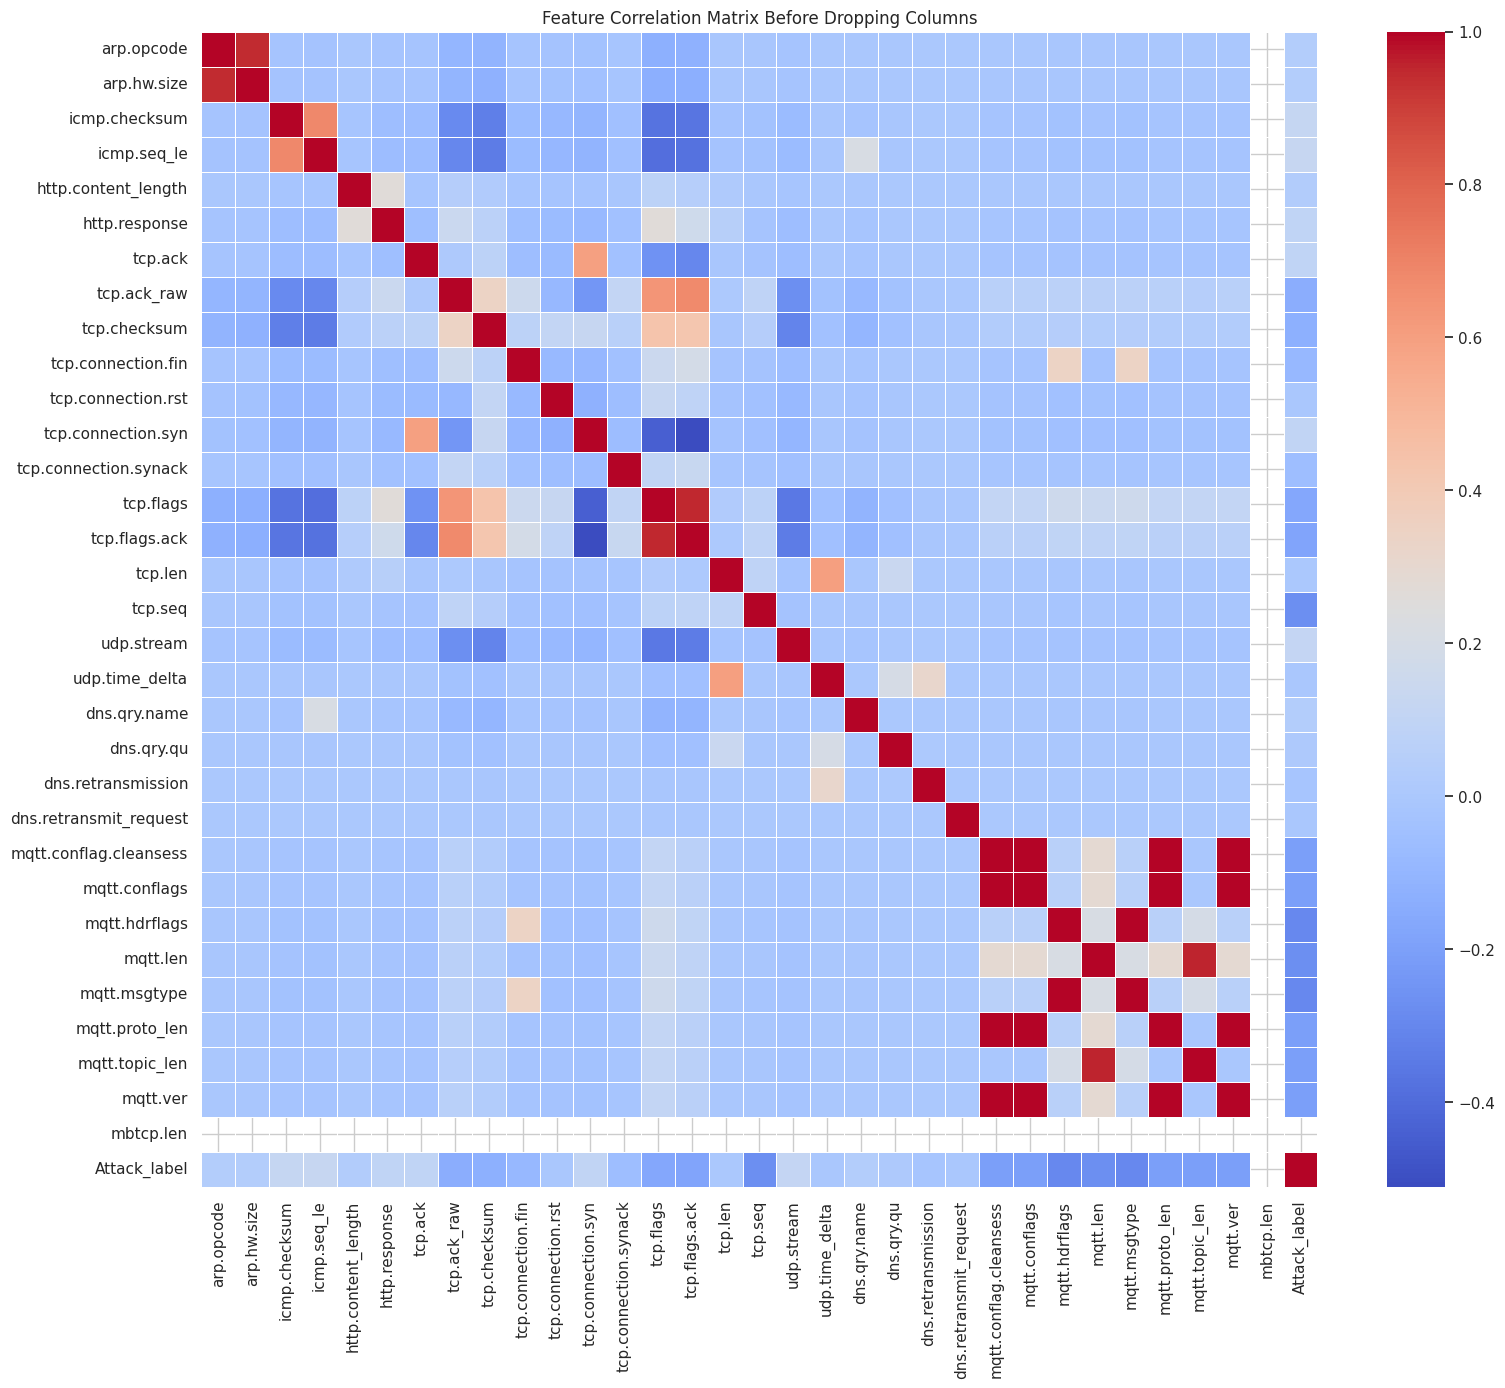


Highly correlated feature pairs (correlation > 0.8):

arp.hw.size  <--->  arp.opcode   | correlation = 0.94
tcp.flags.ack  <--->  tcp.flags   | correlation = 0.95
mqtt.conflags  <--->  mqtt.conflag.cleansess   | correlation = 1.00
mqtt.msgtype  <--->  mqtt.hdrflags   | correlation = 1.00
mqtt.proto_len  <--->  mqtt.conflag.cleansess   | correlation = 1.00
mqtt.proto_len  <--->  mqtt.conflags   | correlation = 1.00
mqtt.topic_len  <--->  mqtt.len   | correlation = 0.95
mqtt.ver  <--->  mqtt.conflag.cleansess   | correlation = 1.00
mqtt.ver  <--->  mqtt.conflags   | correlation = 1.00
mqtt.ver  <--->  mqtt.proto_len   | correlation = 1.00


In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate correlation matrix
numeric_data = data.select_dtypes(include=['number'])
corr_matrix = numeric_data.corr()

# 2. Plot heatmap
plt.figure(figsize=(18, 15))  # adjust size based on how big your dataset is
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix Before Dropping Columns')
plt.show()

# 4. Find pairs with high correlation (absolute correlation > 0.8)
threshold = 0.8

# Take the upper triangle of the correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than threshold
high_corr_pairs = [(col, row, upper.loc[row, col]) 
                   for col in upper.columns 
                   for row in upper.index 
                   if abs(upper.loc[row, col]) > threshold]

# Print the results nicely
print("\nHighly correlated feature pairs (correlation > 0.8):\n")
for col1, col2, corr_value in high_corr_pairs:
    print(f"{col1}  <--->  {col2}   | correlation = {corr_value:.2f}")

In [41]:

data['Attack_label'].groupby(data['tcp.flags.ack']).value_counts(normalize=True)


tcp.flags.ack  Attack_label
0.0            1               0.934072
               0               0.065928
1.0            1               0.794896
               0               0.205104
Name: proportion, dtype: float64

In [42]:


data.info()



<class 'pandas.core.frame.DataFrame'>
Index: 156986 entries, 0 to 157799
Data columns (total 34 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   arp.opcode              156986 non-null  float64
 1   arp.hw.size             156986 non-null  float64
 2   icmp.checksum           156986 non-null  float64
 3   icmp.seq_le             156986 non-null  float64
 4   http.content_length     156986 non-null  float64
 5   http.response           156986 non-null  float64
 6   tcp.ack                 156986 non-null  float64
 7   tcp.ack_raw             156986 non-null  float64
 8   tcp.checksum            156986 non-null  float64
 9   tcp.connection.fin      156986 non-null  float64
 10  tcp.connection.rst      156986 non-null  float64
 11  tcp.connection.syn      156986 non-null  float64
 12  tcp.connection.synack   156986 non-null  float64
 13  tcp.flags               156986 non-null  float64
 14  tcp.flags.ack           1

In [43]:
data['Attack_label'].dtype

dtype('int64')

In [44]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['Attack_label'] = le.fit_transform(data['Attack_label'])

data['Attack_label'].value_counts()



Attack_label
1    132685
0     24301
Name: count, dtype: int64

In [45]:
X = data.drop(['Attack_label', 'Attack_type'], axis=1)
y_label = data['Attack_label']
y_type = data['Attack_type']


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_label, y_test_label = train_test_split(X, y_label, test_size=0.2, random_state=42)


BALANCED RANDOM FOREST

              precision    recall  f1-score   support

      Benign       0.76      0.90      0.83      7290
   Malicious       0.98      0.95      0.96     39806

    accuracy                           0.94     47096
   macro avg       0.87      0.93      0.90     47096
weighted avg       0.95      0.94      0.94     47096



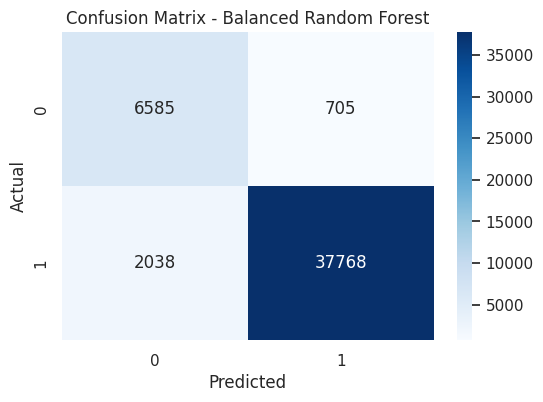

In [47]:
from imblearn.combine import SMOTEENN
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_label, test_size=0.3, stratify=y_label, random_state=42)

# Step 2: Apply SMOTE-ENN (smarter than plain SMOTE)
smote_enn = SMOTEENN(random_state=42)
X_resampled, y_resampled = smote_enn.fit_resample(X_train, y_train)

# Step 3: Use Balanced Random Forest
model = BalancedRandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_resampled, y_resampled)

# Step 4: Predictions
y_pred = model.predict(X_test)

# Step 5: Evaluation
print(classification_report(y_test, y_pred, target_names=["Benign", "Malicious"]))

# Step 6: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Balanced Random Forest")
plt.show()


LOGISTIC REGRESSION

/home/anya/comparative_analysiss-/venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/anya/comparative_analysiss-/venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/anya/comparative_analysiss-/venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/anya/comparative_analysiss-/venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/anya/comparative_analysiss-/venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/anya/comp

Best Parameters: {'C': 10, 'penalty': 'l1'}

Classification Report:
               precision    recall  f1-score   support

           0       0.34      0.75      0.47      7290
           1       0.94      0.74      0.83     39806

    accuracy                           0.74     47096
   macro avg       0.64      0.75      0.65     47096
weighted avg       0.85      0.74      0.77     47096



/home/anya/comparative_analysiss-/venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.



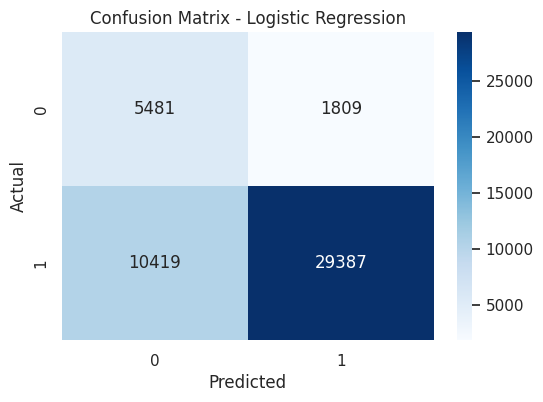

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Define the model with class balancing
log_reg = LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42)

# Step 2: Define hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization strength (smaller = stronger regularization)
    'penalty': ['l1', 'l2']        # L1 for sparsity, L2 for stability
}

# Step 3: Grid search with cross-validation
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Step 4: Predict with best estimator
best_log_reg = grid_search.best_estimator_
y_pred = best_log_reg.predict(X_test)

# Step 5: Evaluation
print("Best Parameters:", grid_search.best_params_)
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=2))

# Step 6: Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


import warnings
from sklearn.exceptions import ConvergenceWarning

# Suppress only convergence warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [49]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


XGBOOST

Fitting 3 folds for each of 324 candidates, totalling 972 fits


/home/anya/comparative_analysiss-/venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [18:42:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/anya/comparative_analysiss-/venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [18:42:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/anya/comparative_analysiss-/venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [18:42:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/anya/comparative_analysiss-/venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [18:42:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 1.0}


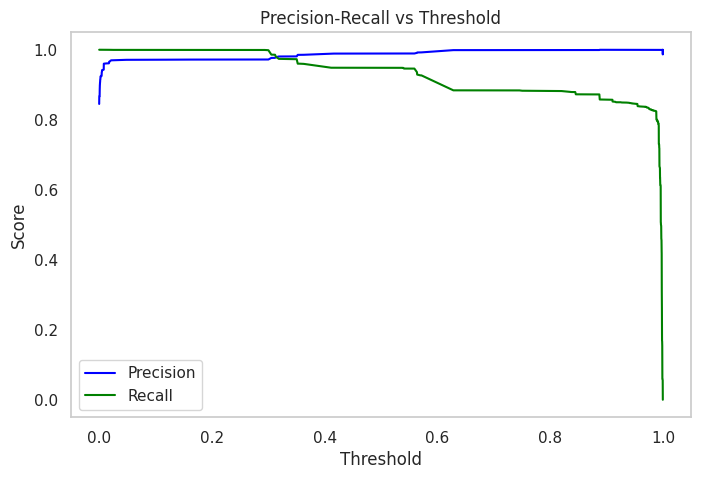


Classification Report (Custom Threshold):
              precision    recall  f1-score   support

      Benign       0.77      0.94      0.85      7290
   Malicious       0.99      0.95      0.97     39806

    accuracy                           0.95     47096
   macro avg       0.88      0.95      0.91     47096
weighted avg       0.96      0.95      0.95     47096



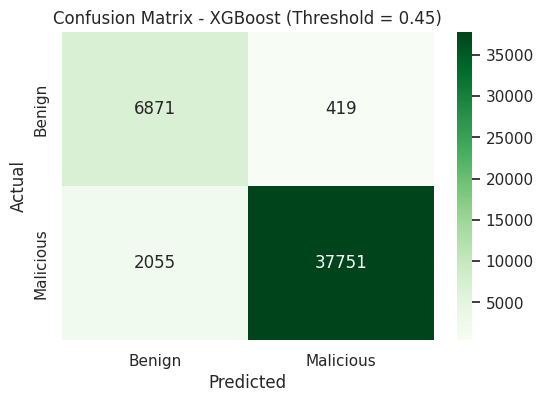

In [50]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, recall_score, precision_recall_curve, make_scorer
from collections import Counter

# Step 1: Handle class imbalance
counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1]

# Step 2: Set up extended parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0]
}

# Step 3: Initialize model
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

# Step 4: Custom scorer to maximize recall on the malicious class (label=1)
scorer = make_scorer(recall_score, pos_label=1)

# Step 5: Grid search with cross-validation
grid = GridSearchCV(
    xgb,
    param_grid,
    scoring=scorer,
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Step 6: Fit model
grid.fit(X_train, y_train)

# Step 7: Evaluate best model
print("Best Parameters:", grid.best_params_)
best_xgb = grid.best_estimator_

# Step 8: Predict probabilities
y_probs = best_xgb.predict_proba(X_test)[:, 1]  # Probability for class 1 (malicious)

# Step 9: Plot precision-recall vs threshold
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label='Precision', color='blue')
plt.plot(thresholds, recall[:-1], label='Recall', color='green')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.grid()
plt.show()

# Step 10: Choose a custom threshold (adjust based on curve)
threshold = 0.45
y_pred = (y_probs >= threshold).astype(int)

# Step 11: Classification report
print("\nClassification Report (Custom Threshold):")
print(classification_report(y_test, y_pred, target_names=["Benign", "Malicious"]))

# Step 12: Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=["Benign", "Malicious"], yticklabels=["Benign", "Malicious"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - XGBoost (Threshold = {threshold})")
plt.show()


DECISION TREE

              precision    recall  f1-score   support

      Benign       0.76      0.91      0.83      7290
   Malicious       0.98      0.95      0.96     39806

    accuracy                           0.94     47096
   macro avg       0.87      0.93      0.90     47096
weighted avg       0.95      0.94      0.94     47096



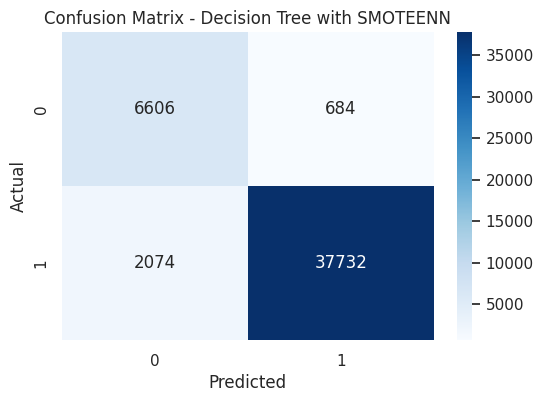

In [51]:
from imblearn.combine import SMOTEENN
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_label, test_size=0.3, stratify=y_label, random_state=42)

# Step 2: Apply SMOTE-ENN
smote_enn = SMOTEENN(random_state=42)
X_resampled, y_resampled = smote_enn.fit_resample(X_train, y_train)

# Step 3: Train Decision Tree
model = DecisionTreeClassifier(random_state=42)
model.fit(X_resampled, y_resampled)

# Step 4: Predictions
y_pred = model.predict(X_test)

# Step 5: Evaluation
print(classification_report(y_test, y_pred, target_names=["Benign", "Malicious"]))

# Step 6: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree with SMOTEENN")
plt.show()


In [52]:
from prettytable import PrettyTable

# Initialize table
table = PrettyTable()
table.field_names = ["Model", "Precision", "Recall", "F1-Score", "Accuracy"]

# Add rows with values you provided
table.add_row(["Balanced Random Forest", "0.95", "0.94", "0.94", "0.94"])
table.add_row(["Logistic Regression",    "0.85", "0.74", "0.77", "0.74"])
table.add_row(["XGBoost",                "0.96", "0.95", "0.95", "0.95"])
table.add_row(["Decision Tree",          "0.95", "0.94", "0.94", "0.94"])

# Print the table
print(table)


+------------------------+-----------+--------+----------+----------+
|         Model          | Precision | Recall | F1-Score | Accuracy |
+------------------------+-----------+--------+----------+----------+
| Balanced Random Forest |    0.95   |  0.94  |   0.94   |   0.94   |
|  Logistic Regression   |    0.85   |  0.74  |   0.77   |   0.74   |
|        XGBoost         |    0.96   |  0.95  |   0.95   |   0.95   |
|     Decision Tree      |    0.95   |  0.94  |   0.94   |   0.94   |
+------------------------+-----------+--------+----------+----------+


I have implemented logistic regression, balancedrandom forest, XGBoost and decision tree.